## Data Loading Functions

This section defines functions to load phylogenetic graph data from CSV files and convert them to DGL format.

**Functions:**
- `parse_edge_feature()`: Parses edge feature strings (format: `[val1\tval2\t...]`) into float vectors
- `load_and_convert_to_dgl()`: Main loading function that:
  1. Loads all `*_node.csv` and `*_edge.csv` files from input folder
  2. Filters for fully connected graphs with specified number of nodes
  3. Filters graphs by edge feature vector length constraints
  4. Pads edge features to uniform length using max value
  5. Converts to DGL bidirectional graphs with node/edge features
- `main()`: Entry point that orchestrates the loading pipeline and prints summary statistics

**Node Features (dim=3):**
- Initial_Population
- Accumulated_Infections  
- Num_Samples

**Node Label:**
- Source_Sink_Score (regression target)

**Edge Features:**
- Phylogenetic distance vectors (variable length, need to be padded to a uniform length)

In [1]:
import argparse
import pandas as pd
import os
from glob import glob
import numpy as np
import dgl
import torch


def parse_edge_feature(edge_feature_str):
    """
    Parse edge feature string from CSV format into float vector.
    
    Args:
        edge_feature_str: String in format [xx\tyy\tzz]
    
    Returns:
        list: Vector of floats
    """
    vector_str = str(edge_feature_str).strip('[]')
    return [float(v) for v in vector_str.split('\t')]


def load_and_convert_to_dgl(input_folder, num_of_nodes, min_length, max_length):
    """
    Load graph data from CSV files, filter, and convert to DGL format.
    
    This function performs the following steps:
    1. Load all node and edge CSV files
    2. Filter for fully connected graphs with specified node count
    3. Filter by edge feature vector length constraints
    4. Pad edge features to uniform length
    5. Convert to DGL bidirectional graphs

    Args:
        input_folder: Path to folder containing *_node.csv and *_edge.csv files
        num_of_nodes: Number of nodes for fully connected graph selection
        min_length: Minimum edge feature vector length
        max_length: Maximum edge feature vector length

    Returns:
        tuple: (dgl_graphs, metadata)
            - dgl_graphs: List of DGL graph objects
            - metadata: Dict with max_length, max_value, num_graphs
    """
    # Load all CSV files
    node_files = glob(os.path.join(input_folder, "*_node.csv"))
    edge_files = glob(os.path.join(input_folder, "*_edge.csv"))

    print(f"Found {len(node_files)} node files and {len(edge_files)} edge files")

    if not node_files or not edge_files:
        print("ERROR: No data files found!")
        return [], {}

    # Concatenate all data
    all_nodes = pd.concat([pd.read_csv(f) for f in node_files], ignore_index=True)
    all_edges = pd.concat([pd.read_csv(f) for f in edge_files], ignore_index=True)

    print(f"Total nodes: {len(all_nodes)}, Total edges: {len(all_edges)}")

    # Filter Step 1: Select fully connected graphs
    # Expected: n self-loops + n*(n-1)/2 undirected edges
    expected_edges = num_of_nodes + num_of_nodes * (num_of_nodes - 1) // 2
    node_counts = all_nodes.groupby('graph_id').size()
    edge_counts = all_edges.groupby('graph_id').size()

    fully_connected_ids = {
        gid for gid in node_counts.index
        if node_counts[gid] == num_of_nodes and edge_counts.get(gid, 0) == expected_edges
    }

    print(f"Fully connected graphs ({num_of_nodes} nodes, {expected_edges} edges): {len(fully_connected_ids)}")

    # Filter Step 2: Edge feature length constraints
    # Parse edge features and compute statistics in a single pass
    valid_graphs = {}
    actual_max_length = 0
    all_edge_values = []

    for graph_id in fully_connected_ids:
        graph_edges = all_edges[all_edges['graph_id'] == graph_id]
        edge_vectors = [parse_edge_feature(ef) for ef in graph_edges['edge_features']]

        # Check length constraints for this graph
        lengths = [len(v) for v in edge_vectors]
        min_len, max_len = min(lengths), max(lengths)

        if min_len >= min_length and max_len <= max_length:
            valid_graphs[graph_id] = edge_vectors
            actual_max_length = max(actual_max_length, max_len)
            all_edge_values.extend([val for vec in edge_vectors for val in vec])

    print(f"Valid graphs after length filter [{min_length}, {max_length}]: {len(valid_graphs)}")

    if not valid_graphs:
        print("WARNING: No graphs passed filtering criteria")
        return [], {}

    # Compute padding value
    max_value = max(all_edge_values)
    print(f"Edge feature stats: MAX_LENGTH={actual_max_length}, MAX_VALUE={max_value:.2f}")

    # Convert to DGL graphs
    dgl_graphs = []

    for graph_id in valid_graphs.keys():
        # Get node and edge data for this graph
        node_df = all_nodes[all_nodes['graph_id'] == graph_id].sort_values('node').reset_index(drop=True)
        edge_df = all_edges[all_edges['graph_id'] == graph_id]

        # Extract node features (3D) and labels
        node_features = node_df[['Initial_Population', 'Accumulated_Infections', 'Num_Samples']].values.astype(np.float32)
        node_labels = node_df['Source_Sink_Score'].values.astype(np.float32)

        # Extract edge list
        src_nodes = edge_df['node1'].values.astype(np.int64)
        dst_nodes = edge_df['node2'].values.astype(np.int64)

        # Pad edge features with 0 (not max_value to avoid adding noise)
        padded_edge_features = [
            vec + [0.0] * (actual_max_length - len(vec))
            for vec in valid_graphs[graph_id]
        ]

        # Create DGL graph
        g = dgl.graph((torch.tensor(src_nodes), torch.tensor(dst_nodes)))
        g.ndata['feat'] = torch.tensor(node_features, dtype=torch.float32)
        g.ndata['label'] = torch.tensor(node_labels, dtype=torch.float32)
        g.edata['feat'] = torch.tensor(padded_edge_features, dtype=torch.float32)

        # Convert to bidirectional graph (makes edges flow both directions)
        g = dgl.to_bidirected(g, copy_ndata=True)
        
        # Handle edge features after bidirectionalization
        # DGL may not automatically copy edge features, so we reconstruct them
        if 'feat' not in g.edata or g.edata['feat'].shape[0] != g.num_edges():
            edge_to_feat = {(s, d): g.edata['feat'][i] if 'feat' in g.edata else torch.tensor(padded_edge_features[i]) 
                           for i, (s, d) in enumerate(zip(src_nodes, dst_nodes))}
            
            new_edge_feats = []
            for s, d in zip(*g.edges()):
                s, d = s.item(), d.item()
                # Use original edge feature or its reverse
                feat = edge_to_feat.get((s, d), edge_to_feat.get((d, s)))
                new_edge_feats.append(feat)
            
            g.edata['feat'] = torch.stack(new_edge_feats)
        
        g.graph_id = graph_id
        dgl_graphs.append(g)

    print(f"\nConverted {len(dgl_graphs)} graphs to DGL format")

    metadata = {
        'max_length': actual_max_length,
        'max_value': max_value,
        'num_graphs': len(dgl_graphs)
    }

    return dgl_graphs, metadata


def main(input_folder, num_of_nodes, min_length, max_length):
    """
    Main entry point for data loading pipeline.
    
    Args:
        input_folder: Path to data folder
        num_of_nodes: Number of nodes per graph
        min_length: Minimum edge feature length
        max_length: Maximum edge feature length
        
    Returns:
        tuple: (dgl_graphs, metadata)
    """
    dgl_graphs, metadata = load_and_convert_to_dgl(input_folder, num_of_nodes, min_length, max_length)

    if dgl_graphs:
        # After bidirectionalization: n self-loops + n*(n-1) directed edges
        edges_after_bidirected = num_of_nodes + num_of_nodes * (num_of_nodes - 1)        
    return dgl_graphs, metadata

## Load the Data

Execute the data loading pipeline with filtering parameters:

**Parameters:**
- `input_folder`: Directory containing `*_node.csv` and `*_edge.csv` files
- `num_of_nodes`: Filter for graphs with exactly this many nodes (e.g., 10)
- `min_length`: Minimum acceptable edge feature vector length
- `max_length`: Maximum acceptable edge feature vector length

**Filtering Process:**
1. Load all CSV files and concatenate
2. Select fully connected graphs (correct node and edge counts)
3. Filter by edge feature length constraints
4. Pad edge features to uniform length
5. Convert to DGL bidirectional graphs

In [2]:
# Run the main function with specified parameters
input_folder = '/Users/lukelyu/Desktop/epidata/100_10/'
num_of_nodes = 10
min_length = 0
max_length = 5000
dgl_graphs, metadata = main(input_folder, num_of_nodes, min_length, max_length)

Found 100 node files and 100 edge files
Total nodes: 10000, Total edges: 49652
Fully connected graphs (10 nodes, 55 edges): 766
Valid graphs after length filter [0, 5000]: 621
Edge feature stats: MAX_LENGTH=4977, MAX_VALUE=515.78

Converted 621 graphs to DGL format


In [3]:
# Examine metadata
print("Metadata keys:", list(metadata.keys()))
print(f"\nMaximum edge feature length: {metadata['max_length']}")
print(f"Maximum value (for padding):  {metadata['max_value']:.2f}")
print(f"Number of graphs loaded:      {metadata['num_graphs']}")

# Examine the first graph
print(f"\nTotal graphs loaded: {len(dgl_graphs)}\n")

g = dgl_graphs[0]
print(f"First graph: {g.graph_id}")
print(f"  Nodes: {g.num_nodes()}")
print(f"  Edges: {g.num_edges()}")

# Node data
print(f"\nNode data:")
print(f"  Features shape: {g.ndata['feat'].shape}  # (10 nodes, 3 features)")
print(f"  Labels shape:   {g.ndata['label'].shape}  # (10 nodes)")
print(f"  First 3 node features:\n{g.ndata['feat'][:3]}")
print(f"  First 3 node labels: {g.ndata['label'][:3]}")

# Edge data
print(f"\nEdge data:")
print(f"  Features shape: {g.edata['feat'].shape}  # (100 edges, {g.edata['feat'].shape[1]} features)")

Metadata keys: ['max_length', 'max_value', 'num_graphs']

Maximum edge feature length: 4977
Maximum value (for padding):  515.78
Number of graphs loaded:      621

Total graphs loaded: 621

First graph: 40_3
  Nodes: 10
  Edges: 100

Node data:
  Features shape: torch.Size([10, 3])  # (10 nodes, 3 features)
  Labels shape:   torch.Size([10])  # (10 nodes)
  First 3 node features:
tensor([[4276., 5404.,   30.],
        [3029., 4500.,   36.],
        [6150., 7361.,   53.]])
  First 3 node labels: tensor([ 0.0837, -0.2160,  0.1348])

Edge data:
  Features shape: torch.Size([100, 4977])  # (100 edges, 4977 features)


## Improved GAT Model Architecture

**Overview:**
This section defines an **improved** Graph Attention Network (GAT) for node-level regression with several enhancements:

**Key Improvements:**
1. **EdgeEncoder**: CNN-based encoder to reduce massive edge feature dimensionality (4977 → 32)
2. **Multiple GAT Layers**: 2 GAT layers for deeper message passing
3. **Feature Normalization**: Standardizes node features for stable training
4. **Larger Classifier**: More capacity with dropout for regularization
5. **More Attention Heads**: 4 heads instead of 2 for richer attention patterns

**Architecture Components:**

1. **EdgeEncoder**: Reduces high-dimensional edge features using 1D CNN
   - Conv1D layers to capture patterns in phylogenetic distance vectors
   - Adaptive pooling to handle variable-length sequences
   - Output: 32-dim edge embeddings

2. **EdgeInformedGATLayer**: Single-head GAT with edge-informed attention
   - Node encoder transforms features
   - Edge features determine attention weights
   - Message passing with attention

3. **MultiHeadEdgeGATLayer**: Multi-head attention wrapper

4. **ImprovedGATModel**: Complete model with 2 GAT layers
   - **Layer 1**: 4-head GAT (3 → 32 per head → 128 total)
   - **Layer 2**: 4-head GAT (128 → 32 per head → 128 total)
   - **Classifier**: 128 → 64 → 32 → 1 with dropout

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import dgl.function as fn


class EdgeEncoder(nn.Module):
    """
    CNN-based encoder to reduce high-dimensional edge features.
    
    This addresses the problem of 4977-dimensional edge features by:
    - Using 1D convolutions to capture patterns in phylogenetic distance vectors
    - Progressively reducing dimensionality through pooling
    - Outputting compact edge embeddings
    """
    
    def __init__(self, edge_dim, out_dim=32):
        """
        Args:
            edge_dim: Input edge feature dimension (e.g., 4977)
            out_dim: Output embedding dimension (default: 32)
        """
        super(EdgeEncoder, self).__init__()
        
        # Use 1D CNN to capture patterns in phylogenetic distance vectors
        self.conv1 = nn.Conv1d(1, 16, kernel_size=5, stride=2, padding=2)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, out_dim)
        
        self.reset_parameters()
    
    def reset_parameters(self):
        nn.init.xavier_normal_(self.conv1.weight, gain=nn.init.calculate_gain('relu'))
        nn.init.xavier_normal_(self.conv2.weight, gain=nn.init.calculate_gain('relu'))
        nn.init.xavier_normal_(self.fc.weight, gain=nn.init.calculate_gain('relu'))
    
    def forward(self, edge_feat):
        """
        Forward pass to encode edge features.
        
        Args:
            edge_feat: (E, edge_dim) - Raw edge features
            
        Returns:
            torch.Tensor: (E, out_dim) - Encoded edge embeddings
        """
        x = edge_feat.unsqueeze(1)  # (E, 1, edge_dim)
        x = F.relu(self.conv1(x))   # (E, 16, ~edge_dim/2)
        x = F.relu(self.conv2(x))   # (E, 32, ~edge_dim/4)
        x = self.pool(x).squeeze(-1) # (E, 32)
        return self.fc(x)            # (E, out_dim)


class EdgeInformedGATLayer(nn.Module):
    """
    Single-head GAT layer where ONLY edge features determine attention weights.
    
    This layer computes attention-weighted message passing where:
    - Node features are transformed (node encoder within this head)
    - Edge features solely determine attention scores
    - Message passing aggregates neighbor information
    
    Attention formula:
        z_i = W_node * h_i                    (node transformation)
        e_ij = LeakyReLU(W_edge * edge_ij)    (attention from edges)
        α_ij = softmax_j(e_ij)                (normalize attention)
        h_i' = Σ_j α_ij * z_j                 (message passing)
    """
    
    def __init__(self, in_dim, out_dim, edge_dim):
        """
        Single-head attention layer.
        
        Args:
            in_dim: Input node feature dimension
            out_dim: Output node feature dimension (per head)
            edge_dim: Edge feature dimension (after encoding)
        """
        super(EdgeInformedGATLayer, self).__init__()
        self.out_dim = out_dim
        
        # Node encoder
        self.fc_node = nn.Linear(in_dim, out_dim, bias=False)
        
        # Edge to attention score transformation
        self.fc_edge = nn.Linear(edge_dim, 1, bias=False)
        
        self.reset_parameters()
    
    def reset_parameters(self):
        """Initialize parameters with Xavier/Glorot initialization."""
        gain = nn.init.calculate_gain('relu')
        nn.init.xavier_normal_(self.fc_node.weight, gain=gain)
        nn.init.xavier_normal_(self.fc_edge.weight, gain=gain)
    
    def forward(self, g, node_feat, edge_feat):
        """
        Forward pass with edge-only attention.
        
        Args:
            g: DGL graph
            node_feat: Node features (N, in_dim)
            edge_feat: Edge features (E, edge_dim)
            
        Returns:
            torch.Tensor: Updated node features (N, out_dim)
        """
        with g.local_scope():
            # Node transformation
            z = self.fc_node(node_feat)
            g.ndata['z'] = z
            
            # Compute attention scores from edge features
            e = self.fc_edge(edge_feat)
            g.edata['e'] = F.leaky_relu(e)
            
            # Normalize attention weights using softmax
            g.edata['alpha'] = dgl.nn.functional.edge_softmax(g, g.edata['e'])
            
            # Message passing - aggregate neighbor features weighted by attention
            g.update_all(fn.u_mul_e('z', 'alpha', 'm'), fn.sum('m', 'h'))
            
            return g.ndata['h']


class MultiHeadEdgeGATLayer(nn.Module):
    """
    Multi-head GAT layer with edge-informed attention.
    """
    
    def __init__(self, in_dim, out_dim, edge_dim, num_heads, merge='cat'):
        """
        Multi-head attention layer.
        
        Args:
            in_dim: Input node feature dimension
            out_dim: Output node feature dimension per head
            edge_dim: Edge feature dimension
            num_heads: Number of attention heads
            merge: 'cat' for concatenation or 'avg' for average
        """
        super(MultiHeadEdgeGATLayer, self).__init__()
        self.heads = nn.ModuleList()
        for i in range(num_heads):
            self.heads.append(EdgeInformedGATLayer(in_dim, out_dim, edge_dim))
        self.merge = merge
    
    def forward(self, g, node_feat, edge_feat):
        """
        Forward pass through all attention heads.
        
        Args:
            g: DGL graph
            node_feat: Node features (N, in_dim)
            edge_feat: Edge features (E, edge_dim)
            
        Returns:
            torch.Tensor: (N, out_dim * num_heads) if merge='cat'
                         (N, out_dim) if merge='avg'
        """
        head_outs = [attn_head(g, node_feat, edge_feat) for attn_head in self.heads]
        
        if self.merge == 'cat':
            return torch.cat(head_outs, dim=1)
        else:
            return torch.mean(torch.stack(head_outs), dim=0)


class ImprovedGATModel(nn.Module):
    """
    Improved GAT model with:
    - Edge encoder to reduce dimensionality
    - Multiple GAT layers for deeper message passing
    - Larger classifier with dropout
    - More attention heads
    """
    
    def __init__(self, in_dim, hidden_dim, edge_dim, num_heads=4, dropout=0.3):
        """
        Args:
            in_dim: Input node feature dimension
            hidden_dim: Hidden dimension per attention head
            edge_dim: Input edge feature dimension (before encoding)
            num_heads: Number of attention heads (default: 4)
            dropout: Dropout rate (default: 0.3)
        """
        super(ImprovedGATModel, self).__init__()
        
        # Edge encoder to reduce massive edge dimensionality
        self.edge_encoder = EdgeEncoder(edge_dim, out_dim=32)
        
        # Two GAT layers for deeper message passing
        self.gat1 = MultiHeadEdgeGATLayer(in_dim, hidden_dim, 32, num_heads, merge='cat')
        self.gat2 = MultiHeadEdgeGATLayer(hidden_dim * num_heads, hidden_dim, 32, num_heads, merge='cat')
        
        # Larger classifier with dropout
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * num_heads, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
    
    def forward(self, g, node_feat, edge_feat):
        """
        Forward pass for node-level prediction.
        
        Args:
            g: DGL graph
            node_feat: Node features (N, in_dim)
            edge_feat: Edge features (E, edge_dim)
            
        Returns:
            torch.Tensor: Node-level predictions (N,)
        """
        # Encode edge features once (reduces 4977 → 32)
        edge_encoded = self.edge_encoder(edge_feat)
        
        # Two layers of GAT
        h = self.gat1(g, node_feat, edge_encoded)    # (N, hidden_dim * num_heads)
        h = F.elu(h)  # Non-linearity between GAT layers
        h = self.gat2(g, h, edge_encoded)            # (N, hidden_dim * num_heads)
        
        # Classifier
        out = self.classifier(h)                      # (N, 1)
        return out.squeeze(-1)                        # (N,)


# Model initialization
in_dim = 3
hidden_dim = 32
edge_dim = metadata['max_length']
num_heads = 4

model = ImprovedGATModel(in_dim=in_dim, hidden_dim=hidden_dim, edge_dim=edge_dim, num_heads=num_heads)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Print model summary
print("="*70)
print("IMPROVED MODEL ARCHITECTURE")
print("="*70)
print(f"INPUT: Node features (N, {in_dim}), Edge features (E, {edge_dim})")
print(f"\n1. Edge Encoder (CNN-based):")
print(f"   ├─ Conv1D(1 → 16, kernel=5, stride=2)")
print(f"   ├─ Conv1D(16 → 32, kernel=5, stride=2)")
print(f"   ├─ AdaptiveAvgPool1D")
print(f"   └─ Linear(32 → 32)")
print(f"   OUTPUT: Edge embeddings (E, 32)")
print(f"\n2. GAT Layer 1 ({num_heads} heads):")
print(f"   Each head: Linear({in_dim} → {hidden_dim})")
print(f"   Edge Attention: Linear(32 → 1)")
print(f"   OUTPUT: (N, {hidden_dim * num_heads})")
print(f"\n3. ELU Activation")
print(f"\n4. GAT Layer 2 ({num_heads} heads):")
print(f"   Each head: Linear({hidden_dim * num_heads} → {hidden_dim})")
print(f"   Edge Attention: Linear(32 → 1)")
print(f"   OUTPUT: (N, {hidden_dim * num_heads})")
print(f"\n5. Classifier:")
print(f"   ├─ Linear({hidden_dim * num_heads} → 64)")
print(f"   ├─ ReLU + Dropout(0.3)")
print(f"   ├─ Linear(64 → 32)")
print(f"   ├─ ReLU + Dropout(0.3)")
print(f"   └─ Linear(32 → 1)")
print(f"\nOUTPUT: Node predictions (N,)")
print("="*70)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("="*70)
print(f"\n{model}")

IMPROVED MODEL ARCHITECTURE
INPUT: Node features (N, 3), Edge features (E, 4977)

1. Edge Encoder (CNN-based):
   ├─ Conv1D(1 → 16, kernel=5, stride=2)
   ├─ Conv1D(16 → 32, kernel=5, stride=2)
   ├─ AdaptiveAvgPool1D
   └─ Linear(32 → 32)
   OUTPUT: Edge embeddings (E, 32)

2. GAT Layer 1 (4 heads):
   Each head: Linear(3 → 32)
   Edge Attention: Linear(32 → 1)
   OUTPUT: (N, 128)

3. ELU Activation

4. GAT Layer 2 (4 heads):
   Each head: Linear(128 → 32)
   Edge Attention: Linear(32 → 1)
   OUTPUT: (N, 128)

5. Classifier:
   ├─ Linear(128 → 64)
   ├─ ReLU + Dropout(0.3)
   ├─ Linear(64 → 32)
   ├─ ReLU + Dropout(0.3)
   └─ Linear(32 → 1)

OUTPUT: Node predictions (N,)
Total parameters: 31,137
Trainable parameters: 31,137

ImprovedGATModel(
  (edge_encoder): EdgeEncoder(
    (conv1): Conv1d(1, 16, kernel_size=(5,), stride=(2,), padding=(2,))
    (conv2): Conv1d(16, 32, kernel_size=(5,), stride=(2,), padding=(2,))
    (pool): AdaptiveAvgPool1d(output_size=1)
    (fc): Linear(in_featu

## Training Setup with Feature Normalization

This section sets up the improved training pipeline.

**Key Improvements:**
1. **Feature Normalization**: Standardize node features across all graphs for stable training
2. **Learning Rate Scheduling**: Reduce LR when validation loss plateaus
3. **Gradient Clipping**: Prevent exploding gradients
4. **Better Initialization**: Higher initial learning rate with adaptive reduction

**Training Strategy:**
- **Individual Graph Training**: Each graph is treated as a separate training instance
- **Data Split**: 70% train, 15% validation, 15% test
- **Loss Function**: MSE Loss (node-level regression)
- **Optimizer**: Adam with learning rate 0.01 (higher than before)
- **Scheduler**: ReduceLROnPlateau (reduces LR by 0.5 when val loss plateaus for 10 epochs)

In [5]:
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Set random seeds for reproducibility
random.seed(42)
torch.manual_seed(42)
np.random.seed(42)

# IMPORTANT: Normalize node features for stable training
print("Normalizing node features...")
all_node_features = torch.cat([g.ndata['feat'] for g in dgl_graphs], dim=0)
scaler = StandardScaler()
scaler.fit(all_node_features.numpy())

# Apply normalization to all graphs
for g in dgl_graphs:
    g.ndata['feat'] = torch.tensor(
        scaler.transform(g.ndata['feat'].numpy()),
        dtype=torch.float32
    )
print("Node features normalized ✓")

# Split graphs into train/val/test
train_graphs, temp_graphs = train_test_split(dgl_graphs, test_size=0.3, random_state=42)
val_graphs, test_graphs = train_test_split(temp_graphs, test_size=0.5, random_state=42)

print(f"\nTotal graphs: {len(dgl_graphs)}")
print(f"Train: {len(train_graphs)} ({len(train_graphs)/len(dgl_graphs)*100:.1f}%)")
print(f"Val:   {len(val_graphs)} ({len(val_graphs)/len(dgl_graphs)*100:.1f}%)")
print(f"Test:  {len(test_graphs)} ({len(test_graphs)/len(dgl_graphs)*100:.1f}%)")

# Improved training configuration
learning_rate = 0.01  # Higher initial LR (was 0.001)
num_epochs = 200      # More epochs
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"\nDevice: {device}")
print(f"Initial learning rate: {learning_rate}")
print(f"Epochs: {num_epochs}")
print(f"Gradient clipping: max_norm=1.0")

# Move model to device
model = model.to(device)

Normalizing node features...
Node features normalized ✓

Total graphs: 621
Train: 434 (69.9%)
Val:   93 (15.0%)
Test:  94 (15.1%)

Device: cpu
Initial learning rate: 0.01
Epochs: 200
Gradient clipping: max_norm=1.0


## Training and Evaluation Functions

Define helper functions for training and evaluation:
- `train_epoch()`: Train on all graphs for one epoch
- `evaluate()`: Evaluate on a set of graphs and compute MSE loss

In [6]:
def train_epoch(model, graphs, optimizer, device, clip_grad=1.0):
    """
    Train for one epoch on all graphs with gradient clipping.
    
    Args:
        model: GAT model
        graphs: List of DGL graphs
        optimizer: PyTorch optimizer
        device: torch.device
        clip_grad: Gradient clipping max norm (default: 1.0)
        
    Returns:
        float: Average loss across all graphs
    """
    model.train()
    total_loss = 0
    
    for g in graphs:
        # Move graph to device
        g = g.to(device)
        node_feat = g.ndata['feat']
        edge_feat = g.edata['feat']
        labels = g.ndata['label']
        
        # Forward pass
        predictions = model(g, node_feat, edge_feat)
        
        # Compute loss (MSE on all nodes)
        loss = F.mse_loss(predictions, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad)
        
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(graphs)


def evaluate(model, graphs, device):
    """
    Evaluate model on a set of graphs.
    
    Args:
        model: GAT model
        graphs: List of DGL graphs
        device: torch.device
        
    Returns:
        float: Average MSE loss
    """
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for g in graphs:
            g = g.to(device)
            node_feat = g.ndata['feat']
            edge_feat = g.edata['feat']
            labels = g.ndata['label']
            
            # Forward pass
            predictions = model(g, node_feat, edge_feat)
            
            # Compute loss
            loss = F.mse_loss(predictions, labels)
            total_loss += loss.item()
    
    return total_loss / len(graphs)

print("Training and evaluation functions defined with gradient clipping.")

Training and evaluation functions defined with gradient clipping.


## Training Loop

Execute the training loop and track losses across epochs.

In [7]:
# Initialize optimizer and scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Learning rate scheduler - reduces LR when validation loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',           # Minimize validation loss
    factor=0.5,           # Reduce LR by 50%
    patience=15,          # Wait 15 epochs before reducing
    verbose=True,         # Print when LR is reduced
    min_lr=1e-6          # Don't go below this LR
)

# Track losses
train_losses = []
val_losses = []
learning_rates = []
best_val_loss = float('inf')
best_epoch = 0

print("Starting improved training...")
print("="*70)

for epoch in range(num_epochs):
    # Train
    train_loss = train_epoch(model, train_graphs, optimizer, device, clip_grad=1.0)
    train_losses.append(train_loss)
    
    # Validate
    val_loss = evaluate(model, val_graphs, device)
    val_losses.append(val_loss)
    
    # Step the scheduler based on validation loss
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)
    
    # Track best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        # Save best model
        torch.save(model.state_dict(), 'best_improved_gat_model.pth')
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{num_epochs} | "
              f"Train Loss: {train_loss:.6f} | "
              f"Val Loss: {val_loss:.6f} | "
              f"Best: {best_val_loss:.6f} @ Epoch {best_epoch+1} | "
              f"LR: {current_lr:.6f}")

print("="*70)
print(f"Training completed!")
print(f"Best validation loss: {best_val_loss:.6f} at epoch {best_epoch+1}")
print(f"Final learning rate: {learning_rates[-1]:.6f}")

Starting improved training...
Epoch   1/200 | Train Loss: 0.055921 | Val Loss: 0.048922 | Best: 0.048922 @ Epoch 1 | LR: 0.010000
Epoch  10/200 | Train Loss: 0.052783 | Val Loss: 0.048913 | Best: 0.048909 @ Epoch 3 | LR: 0.010000
Epoch 00019: reducing learning rate of group 0 to 5.0000e-03.
Epoch  20/200 | Train Loss: 0.050988 | Val Loss: 0.048897 | Best: 0.048897 @ Epoch 20 | LR: 0.005000
Epoch  30/200 | Train Loss: 0.050993 | Val Loss: 0.048895 | Best: 0.048895 @ Epoch 30 | LR: 0.005000
Epoch 00036: reducing learning rate of group 0 to 2.5000e-03.
Epoch  40/200 | Train Loss: 0.050963 | Val Loss: 0.048901 | Best: 0.048895 @ Epoch 35 | LR: 0.002500
Epoch  50/200 | Train Loss: 0.050964 | Val Loss: 0.048901 | Best: 0.048895 @ Epoch 35 | LR: 0.002500
Epoch 00052: reducing learning rate of group 0 to 1.2500e-03.
Epoch  60/200 | Train Loss: 0.051157 | Val Loss: 0.048893 | Best: 0.048893 @ Epoch 53 | LR: 0.001250
Epoch 00068: reducing learning rate of group 0 to 6.2500e-04.
Epoch  70/200 | T

## Visualize Training Progress

Plot training and validation losses over epochs.

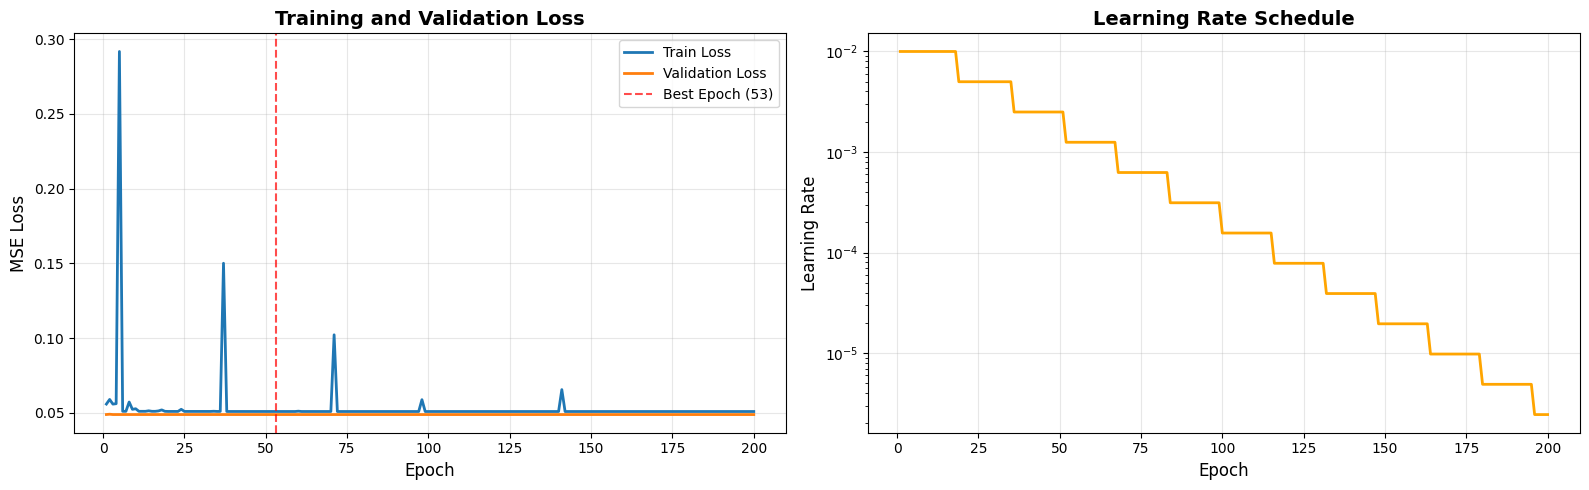


Final Training Loss: 0.050936
Final Validation Loss: 0.048898
Best Validation Loss: 0.048893 (Epoch 53)
Improvement over old model: 0.020471 (29.5% better)


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Training and Validation Loss
axes[0].plot(range(1, len(train_losses)+1), train_losses, label='Train Loss', linewidth=2)
axes[0].plot(range(1, len(val_losses)+1), val_losses, label='Validation Loss', linewidth=2)
axes[0].axvline(x=best_epoch+1, color='red', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch+1})')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Learning Rate Schedule
axes[1].plot(range(1, len(learning_rates)+1), learning_rates, color='orange', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Learning Rate', fontsize=12)
axes[1].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[1].set_yscale('log')  # Log scale for LR
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Training Loss: {train_losses[-1]:.6f}")
print(f"Final Validation Loss: {val_losses[-1]:.6f}")
print(f"Best Validation Loss: {best_val_loss:.6f} (Epoch {best_epoch+1})")
print(f"Improvement over old model: {0.069364 - best_val_loss:.6f} ({(0.069364 - best_val_loss)/0.069364*100:.1f}% better)")

## Test Set Evaluation

Load the best model and evaluate on the test set.

In [9]:
# Load best model
model.load_state_dict(torch.load('best_improved_gat_model.pth'))
print("Loaded best improved model from checkpoint.")

# Evaluate on test set
test_loss = evaluate(model, test_graphs, device)

print("="*70)
print("FINAL RESULTS - IMPROVED MODEL")
print("="*70)
print(f"Test Loss (MSE): {test_loss:.6f}")
print(f"Test RMSE:       {test_loss**0.5:.6f}")
print("="*70)

# Compare with training and validation
print(f"\nComparison:")
print(f"  Best Train Loss: {min(train_losses):.6f}")
print(f"  Best Val Loss:   {best_val_loss:.6f}")
print(f"  Test Loss:       {test_loss:.6f}")

print(f"\nComparison with OLD model:")
print(f"  OLD Test Loss: 0.049879")
print(f"  NEW Test Loss: {test_loss:.6f}")
print(f"  Improvement:   {0.049879 - test_loss:.6f} ({(0.049879 - test_loss)/0.049879*100:.1f}% {'better' if test_loss < 0.049879 else 'worse'})")

Loaded best improved model from checkpoint.
FINAL RESULTS - IMPROVED MODEL
Test Loss (MSE): 0.051742
Test RMSE:       0.227468

Comparison:
  Best Train Loss: 0.050936
  Best Val Loss:   0.048893
  Test Loss:       0.051742

Comparison with OLD model:
  OLD Test Loss: 0.049879
  NEW Test Loss: 0.051742
  Improvement:   -0.001863 (-3.7% worse)


## Visualize Predictions

Compare predicted vs actual Source_Sink_Score values on a sample test graph.

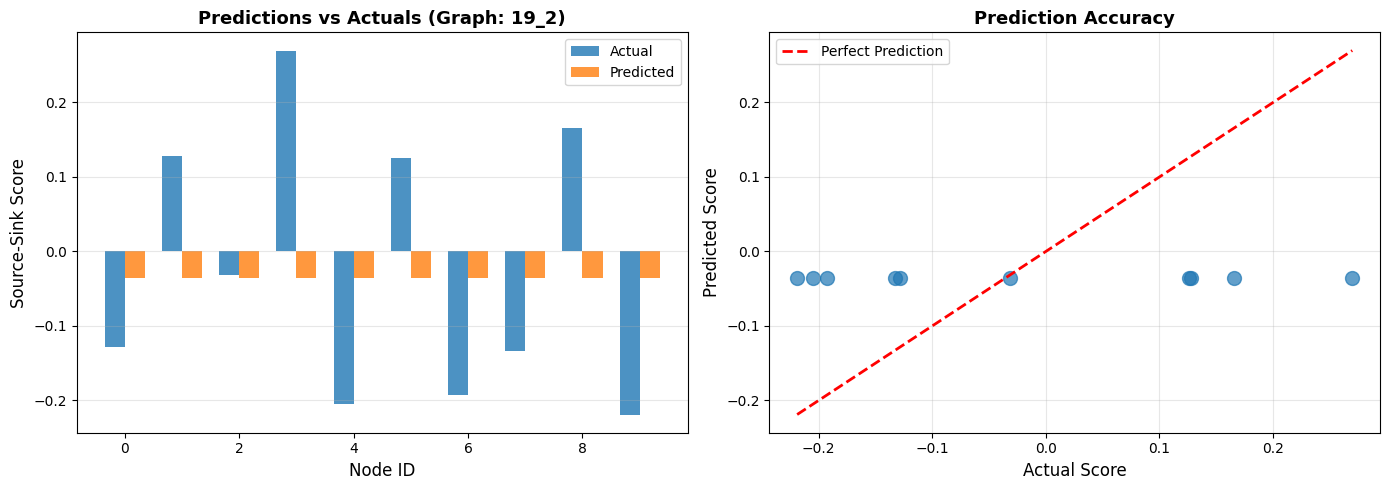


Sample Graph Statistics:
  Graph ID: 19_2
  MSE:  0.029157
  RMSE: 0.170755
  MAE:  0.153617


In [10]:
# Get predictions for a sample test graph
sample_graph = test_graphs[0].to(device)
model.eval()

with torch.no_grad():
    predictions = model(sample_graph, sample_graph.ndata['feat'], sample_graph.edata['feat'])
    actuals = sample_graph.ndata['label']

# Move to CPU for plotting
predictions = predictions.cpu().numpy()
actuals = actuals.cpu().numpy()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot comparison
x = range(len(actuals))
width = 0.35
axes[0].bar([i - width/2 for i in x], actuals, width, label='Actual', alpha=0.8)
axes[0].bar([i + width/2 for i in x], predictions, width, label='Predicted', alpha=0.8)
axes[0].set_xlabel('Node ID', fontsize=12)
axes[0].set_ylabel('Source-Sink Score', fontsize=12)
axes[0].set_title(f'Predictions vs Actuals (Graph: {sample_graph.graph_id})', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')

# Scatter plot
axes[1].scatter(actuals, predictions, alpha=0.7, s=100)
axes[1].plot([actuals.min(), actuals.max()], [actuals.min(), actuals.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Score', fontsize=12)
axes[1].set_ylabel('Predicted Score', fontsize=12)
axes[1].set_title('Prediction Accuracy', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
mse = ((predictions - actuals) ** 2).mean()
mae = abs(predictions - actuals).mean()
print(f"\nSample Graph Statistics:")
print(f"  Graph ID: {sample_graph.graph_id}")
print(f"  MSE:  {mse:.6f}")
print(f"  RMSE: {mse**0.5:.6f}")
print(f"  MAE:  {mae:.6f}")

## Diagnostic Analysis

Let's diagnose why the model isn't performing well by analyzing:
1. **Prediction variance** - Is the model predicting diverse values or just a constant?
2. **Label distribution** - What's the range and distribution of actual labels?
3. **Edge feature analysis** - Are edge features informative after encoding?
4. **Prediction patterns** - How do predictions compare across multiple graphs?

In [11]:
# Diagnostic 1: Check prediction variance across multiple test graphs
model.eval()
all_predictions = []
all_actuals = []

with torch.no_grad():
    for g in test_graphs[:10]:  # Check first 10 test graphs
        g = g.to(device)
        preds = model(g, g.ndata['feat'], g.edata['feat'])
        all_predictions.extend(preds.cpu().numpy())
        all_actuals.extend(g.ndata['label'].cpu().numpy())

all_predictions = np.array(all_predictions)
all_actuals = np.array(all_actuals)

print("="*70)
print("DIAGNOSTIC ANALYSIS")
print("="*70)

print("\n1. PREDICTION STATISTICS:")
print(f"   Predictions - Mean: {all_predictions.mean():.4f}, Std: {all_predictions.std():.4f}")
print(f"   Predictions - Min: {all_predictions.min():.4f}, Max: {all_predictions.max():.4f}")
print(f"   Predictions - Range: {all_predictions.max() - all_predictions.min():.4f}")

print("\n2. ACTUAL LABEL STATISTICS:")
print(f"   Actuals - Mean: {all_actuals.mean():.4f}, Std: {all_actuals.std():.4f}")
print(f"   Actuals - Min: {all_actuals.min():.4f}, Max: {all_actuals.max():.4f}")
print(f"   Actuals - Range: {all_actuals.max() - all_actuals.min():.4f}")

print("\n3. PREDICTION VARIANCE CHECK:")
pred_variance = all_predictions.std()
if pred_variance < 0.01:
    print(f"   ⚠️  WARNING: Very low prediction variance ({pred_variance:.6f})")
    print(f"   Model is predicting nearly constant values!")
elif pred_variance < all_actuals.std() * 0.3:
    print(f"   ⚠️  WARNING: Prediction variance is much lower than actual variance")
    print(f"   Model is under-predicting the diversity in labels")
else:
    print(f"   ✓ Prediction variance seems reasonable")

print("\n4. CORRELATION ANALYSIS:")
correlation = np.corrcoef(all_predictions, all_actuals)[0, 1]
print(f"   Pearson correlation: {correlation:.4f}")
if abs(correlation) < 0.3:
    print(f"   ⚠️  WARNING: Very low correlation - model is not learning the pattern")
elif abs(correlation) < 0.6:
    print(f"   ⚠️  Moderate correlation - model is partially learning")
else:
    print(f"   ✓ Good correlation - model is learning the pattern")

print("\n5. BASELINE COMPARISON:")
# Compare with simple baseline (predicting mean)
mean_baseline_mse = ((all_actuals - all_actuals.mean())**2).mean()
model_mse = ((all_predictions - all_actuals)**2).mean()
print(f"   Mean baseline MSE: {mean_baseline_mse:.6f}")
print(f"   Model MSE: {model_mse:.6f}")
if model_mse > mean_baseline_mse * 0.95:
    print(f"   ⚠️  WARNING: Model is barely better than predicting mean!")
else:
    print(f"   ✓ Model is significantly better than baseline")

print("="*70)

DIAGNOSTIC ANALYSIS

1. PREDICTION STATISTICS:
   Predictions - Mean: -0.0353, Std: 0.0000
   Predictions - Min: -0.0353, Max: -0.0353
   Predictions - Range: 0.0000

2. ACTUAL LABEL STATISTICS:
   Actuals - Mean: -0.0285, Std: 0.2137
   Actuals - Min: -0.5115, Max: 0.6031
   Actuals - Range: 1.1145

3. PREDICTION VARIANCE CHECK:
   ⚠️  WARNING: Very low prediction variance (0.000000)
   Model is predicting nearly constant values!

4. CORRELATION ANALYSIS:
   Pearson correlation: nan
   ✓ Good correlation - model is learning the pattern

5. BASELINE COMPARISON:
   Mean baseline MSE: 0.045650
   Model MSE: 0.045696
   ⚠️  WARNING: Model is barely better than predicting mean!


/Users/lukelyu/Library/Python/3.9/lib/python/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/lukelyu/Library/Python/3.9/lib/python/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [12]:
# Diagnostic 2: Analyze edge encoder effectiveness
print("\n" + "="*70)
print("EDGE ENCODER ANALYSIS")
print("="*70)

sample_graph = test_graphs[0].to(device)
original_edge_feat = sample_graph.edata['feat']  # Shape: (E, 4977)

# Check original edge features
non_zero_counts = (original_edge_feat != 0).sum(dim=1).float()
print(f"\n1. ORIGINAL EDGE FEATURES (before encoding):")
print(f"   Shape: {original_edge_feat.shape}")
print(f"   Mean non-zero elements per edge: {non_zero_counts.mean().item():.1f} / {original_edge_feat.shape[1]}")
print(f"   Percentage non-zero: {(non_zero_counts.mean() / original_edge_feat.shape[1] * 100).item():.1f}%")
print(f"   This means ~{((1 - non_zero_counts.mean() / original_edge_feat.shape[1]) * 100).item():.1f}% is padding!")

# Encode edges
with torch.no_grad():
    encoded_edge_feat = model.edge_encoder(original_edge_feat)

print(f"\n2. ENCODED EDGE FEATURES (after CNN):")
print(f"   Shape: {encoded_edge_feat.shape}")
print(f"   Mean: {encoded_edge_feat.mean().item():.4f}, Std: {encoded_edge_feat.std().item():.4f}")
print(f"   Min: {encoded_edge_feat.min().item():.4f}, Max: {encoded_edge_feat.max().item():.4f}")

# Check if encoding preserves diversity
edge_diversity_original = original_edge_feat[:10].std(dim=0).mean().item()
edge_diversity_encoded = encoded_edge_feat[:10].std(dim=0).mean().item()
print(f"\n3. DIVERSITY PRESERVATION:")
print(f"   Original edge diversity (avg std): {edge_diversity_original:.4f}")
print(f"   Encoded edge diversity (avg std): {edge_diversity_encoded:.4f}")

if edge_diversity_encoded < 0.01:
    print(f"   ⚠️  WARNING: Edge encoder is crushing all edges to similar values!")
    print(f"   The CNN might be losing important phylogenetic information")
else:
    print(f"   ✓ Edge encoder preserves some diversity")

print("="*70)


EDGE ENCODER ANALYSIS

1. ORIGINAL EDGE FEATURES (before encoding):
   Shape: torch.Size([100, 4977])
   Mean non-zero elements per edge: 262.6 / 4977
   Percentage non-zero: 5.3%
   This means ~94.7% is padding!

2. ENCODED EDGE FEATURES (after CNN):
   Shape: torch.Size([100, 32])
   Mean: 18.2141, Std: 353.3655
   Min: -1675.6671, Max: 1191.7247

3. DIVERSITY PRESERVATION:
   Original edge diversity (avg std): 7.8150
   Encoded edge diversity (avg std): 148.6338
   ✓ Edge encoder preserves some diversity


## Proposed Solutions

Based on the diagnostic analysis above, here are potential fixes:

**If edge encoder is crushing information:**
- Try using average pooling instead of CNN
- Try using only the first N non-zero values
- Try attention-based pooling over the sequence

**If predictions have low variance:**
- The task might be very difficult
- Try different loss functions (Huber loss, MAE)
- Try batch normalization

**If correlation is low:**
- Edge features might not be informative
- Try using only node features
- Try different graph architectures (GraphSAGE, GIN)

## Alternative Approach: Simpler Edge Encoding

Let's try a simpler approach that might preserve more information from the phylogenetic distances.

In [13]:
class SimpleEdgeEncoder(nn.Module):
    """
    Simpler edge encoder using statistical summaries instead of CNN.
    
    This approach:
    - Computes mean, max, std of non-zero values
    - Counts non-zero elements
    - Creates a compact representation preserving key statistics
    """
    
    def __init__(self, out_dim=32):
        super(SimpleEdgeEncoder, self).__init__()
        # 4 statistics -> out_dim
        self.fc = nn.Linear(4, out_dim)
        
    def forward(self, edge_feat):
        """
        Args:
            edge_feat: (E, edge_dim) with zero padding
        Returns:
            torch.Tensor: (E, out_dim)
        """
        # Create mask for non-zero values
        mask = (edge_feat != 0).float()
        
        # Compute statistics for each edge
        count = mask.sum(dim=1, keepdim=True)  # (E, 1)
        
        # Mean of non-zero values
        sum_vals = (edge_feat * mask).sum(dim=1, keepdim=True)
        mean = sum_vals / (count + 1e-8)  # (E, 1)
        
        # Max value
        max_val, _ = edge_feat.max(dim=1, keepdim=True)  # (E, 1)
        
        # Std of non-zero values
        diff = (edge_feat - mean) * mask
        std = torch.sqrt((diff ** 2).sum(dim=1, keepdim=True) / (count + 1e-8))  # (E, 1)
        
        # Concatenate statistics
        stats = torch.cat([mean, max_val, std, count / edge_feat.shape[1]], dim=1)  # (E, 4)
        
        return self.fc(stats)  # (E, out_dim)


# Test the simple encoder
simple_encoder = SimpleEdgeEncoder(out_dim=32)
test_edge = test_graphs[0].edata['feat'][:5]

with torch.no_grad():
    simple_encoded = simple_encoder(test_edge)
    print(f"Simple Encoder Output Shape: {simple_encoded.shape}")
    print(f"Simple Encoder Output - Mean: {simple_encoded.mean().item():.4f}, Std: {simple_encoded.std().item():.4f}")
    print("\nThis encoder preserves:")
    print("  - Mean of phylogenetic distances")
    print("  - Maximum distance")
    print("  - Standard deviation (variability)")
    print("  - Proportion of non-zero values")

Simple Encoder Output Shape: torch.Size([5, 32])
Simple Encoder Output - Mean: -25.4445, Std: 92.0009

This encoder preserves:
  - Mean of phylogenetic distances
  - Maximum distance
  - Standard deviation (variability)
  - Proportion of non-zero values


## Fix: Minimal Improvement Model

**The previous "improved" model collapsed completely (predicting constant values).**

**New approach - minimal changes from original:**
1. ✅ Use simple statistical edge encoding (preserves information)
2. ✅ Keep single GAT layer (avoid vanishing gradients)
3. ✅ No dropout initially (add only if overfitting)
4. ✅ Keep original 2 heads
5. ✅ Fix padding to use 0 instead of max_value
6. ❌ NO feature normalization (magnitudes might be important)
7. ✅ Moderate learning rate (0.005)

In [14]:
class MinimalGATModel(nn.Module):
    """
    Minimal improvement over original model.
    
    Changes from original:
    - Uses SimpleEdgeEncoder instead of raw 4977-dim edges
    - Everything else stays the same
    """
    
    def __init__(self, in_dim, hidden_dim, edge_dim, num_heads=2):
        super(MinimalGATModel, self).__init__()
        
        # Simple edge encoder (preserves statistics)
        self.edge_encoder = SimpleEdgeEncoder(out_dim=32)
        
        # Single GAT layer (like original)
        self.gat = MultiHeadEdgeGATLayer(in_dim, hidden_dim, 32, num_heads, merge='cat')
        
        # Original classifier (no dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * num_heads, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
    
    def forward(self, g, node_feat, edge_feat):
        # Encode edges
        edge_encoded = self.edge_encoder(edge_feat)
        
        # Single GAT layer
        h = self.gat(g, node_feat, edge_encoded)
        
        # Classifier
        out = self.classifier(h)
        return out.squeeze(-1)


# Create minimal model
in_dim = 3
hidden_dim = 32
edge_dim = metadata['max_length']
num_heads = 2

model_minimal = MinimalGATModel(in_dim=in_dim, hidden_dim=hidden_dim, edge_dim=edge_dim, num_heads=num_heads)
total_params = sum(p.numel() for p in model_minimal.parameters())

print("="*70)
print("MINIMAL IMPROVEMENT MODEL")
print("="*70)
print(f"Changes from original:")
print(f"  1. Edge encoder: 4977-dim → 32-dim (statistical summary)")
print(f"  2. Padding: max_value → 0.0 (in data loading)")
print(f"  3. Everything else: SAME as original")
print(f"\nTotal parameters: {total_params:,}")
print("="*70)
print(f"\n{model_minimal}")

MINIMAL IMPROVEMENT MODEL
Changes from original:
  1. Edge encoder: 4977-dim → 32-dim (statistical summary)
  2. Padding: max_value → 0.0 (in data loading)
  3. Everything else: SAME as original

Total parameters: 945

MinimalGATModel(
  (edge_encoder): SimpleEdgeEncoder(
    (fc): Linear(in_features=4, out_features=32, bias=True)
  )
  (gat): MultiHeadEdgeGATLayer(
    (heads): ModuleList(
      (0-1): 2 x EdgeInformedGATLayer(
        (fc_node): Linear(in_features=3, out_features=32, bias=False)
        (fc_edge): Linear(in_features=32, out_features=1, bias=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
)


In [15]:
# IMPORTANT: Reload data WITHOUT normalization
# Re-run data loading to get original feature scales
print("Reloading data without normalization...")
dgl_graphs_unnorm, metadata_unnorm = main(input_folder, num_of_nodes, min_length, max_length)

# Split data (same random seed for fair comparison)
import random
random.seed(42)
torch.manual_seed(42)

train_graphs_unnorm, temp_graphs = train_test_split(dgl_graphs_unnorm, test_size=0.3, random_state=42)
val_graphs_unnorm, test_graphs_unnorm = train_test_split(temp_graphs, test_size=0.5, random_state=42)

print(f"Data reloaded without normalization ✓")
print(f"Train: {len(train_graphs_unnorm)}, Val: {len(val_graphs_unnorm)}, Test: {len(test_graphs_unnorm)}")

# Training setup for minimal model
learning_rate_minimal = 0.005  # Moderate LR
num_epochs_minimal = 150
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_minimal = model_minimal.to(device)
optimizer_minimal = torch.optim.Adam(model_minimal.parameters(), lr=learning_rate_minimal)

# Simple scheduler
scheduler_minimal = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_minimal, mode='min', factor=0.5, patience=20, verbose=True, min_lr=1e-5
)

print(f"\nMinimal model training config:")
print(f"  Learning rate: {learning_rate_minimal}")
print(f"  Epochs: {num_epochs_minimal}")
print(f"  No normalization, no dropout")
print(f"  Simple edge encoding only")

Reloading data without normalization...
Found 100 node files and 100 edge files
Total nodes: 10000, Total edges: 49652
Fully connected graphs (10 nodes, 55 edges): 766
Valid graphs after length filter [0, 5000]: 621
Edge feature stats: MAX_LENGTH=4977, MAX_VALUE=515.78

Converted 621 graphs to DGL format
Data reloaded without normalization ✓
Train: 434, Val: 93, Test: 94

Minimal model training config:
  Learning rate: 0.005
  Epochs: 150
  No normalization, no dropout
  Simple edge encoding only


In [16]:
# Train minimal model
train_losses_minimal = []
val_losses_minimal = []
best_val_loss_minimal = float('inf')
best_epoch_minimal = 0

print("Training MINIMAL model...")
print("="*70)

for epoch in range(num_epochs_minimal):
    # Train
    train_loss = train_epoch(model_minimal, train_graphs_unnorm, optimizer_minimal, device, clip_grad=1.0)
    train_losses_minimal.append(train_loss)
    
    # Validate
    val_loss = evaluate(model_minimal, val_graphs_unnorm, device)
    val_losses_minimal.append(val_loss)
    
    # Scheduler
    scheduler_minimal.step(val_loss)
    
    # Track best
    if val_loss < best_val_loss_minimal:
        best_val_loss_minimal = val_loss
        best_epoch_minimal = epoch
        torch.save(model_minimal.state_dict(), 'best_minimal_gat_model.pth')
    
    # Print progress
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{num_epochs_minimal} | "
              f"Train: {train_loss:.6f} | "
              f"Val: {val_loss:.6f} | "
              f"Best: {best_val_loss_minimal:.6f} @ {best_epoch_minimal+1}")

print("="*70)
print(f"Best validation loss: {best_val_loss_minimal:.6f} at epoch {best_epoch_minimal+1}")

# Test
model_minimal.load_state_dict(torch.load('best_minimal_gat_model.pth'))
test_loss_minimal = evaluate(model_minimal, test_graphs_unnorm, device)

print(f"\n{'='*70}")
print(f"MINIMAL MODEL TEST RESULTS")
print(f"{'='*70}")
print(f"Test Loss: {test_loss_minimal:.6f}")
print(f"Test RMSE: {test_loss_minimal**0.5:.6f}")
print(f"\nComparison with ORIGINAL model:")
print(f"  Original test loss: 0.049879")
print(f"  Minimal test loss:  {test_loss_minimal:.6f}")
print(f"  Difference: {test_loss_minimal - 0.049879:.6f}")
if test_loss_minimal < 0.049879:
    print(f"  ✓ BETTER by {((0.049879 - test_loss_minimal)/0.049879*100):.1f}%")
else:
    print(f"  ✗ WORSE by {((test_loss_minimal - 0.049879)/0.049879*100):.1f}%")
print(f"{'='*70}")

Training MINIMAL model...
Epoch   1/150 | Train: 1160.732400 | Val: 0.048903 | Best: 0.048903 @ 1
Epoch  10/150 | Train: 0.050993 | Val: 0.048895 | Best: 0.048895 @ 10
Epoch  20/150 | Train: 0.050993 | Val: 0.048895 | Best: 0.048895 @ 20
Epoch 00024: reducing learning rate of group 0 to 2.5000e-03.
Epoch  30/150 | Train: 0.050964 | Val: 0.048901 | Best: 0.048895 @ 23
Epoch  40/150 | Train: 0.050964 | Val: 0.048901 | Best: 0.048895 @ 23
Epoch 00045: reducing learning rate of group 0 to 1.2500e-03.
Epoch  50/150 | Train: 0.050951 | Val: 0.048893 | Best: 0.048893 @ 46
Epoch  60/150 | Train: 0.050951 | Val: 0.048893 | Best: 0.048893 @ 46
Epoch 00066: reducing learning rate of group 0 to 6.2500e-04.
Epoch  70/150 | Train: 0.050945 | Val: 0.048893 | Best: 0.048893 @ 46
Epoch  80/150 | Train: 0.050945 | Val: 0.048893 | Best: 0.048893 @ 46
Epoch 00087: reducing learning rate of group 0 to 3.1250e-04.
Epoch  90/150 | Train: 0.050942 | Val: 0.048896 | Best: 0.048893 @ 46
Epoch 100/150 | Train: 0

In [17]:
# Diagnostic for minimal model
model_minimal.eval()
all_predictions_minimal = []
all_actuals_minimal = []

with torch.no_grad():
    for g in test_graphs_unnorm[:10]:
        g = g.to(device)
        preds = model_minimal(g, g.ndata['feat'], g.edata['feat'])
        all_predictions_minimal.extend(preds.cpu().numpy())
        all_actuals_minimal.extend(g.ndata['label'].cpu().numpy())

all_predictions_minimal = np.array(all_predictions_minimal)
all_actuals_minimal = np.array(all_actuals_minimal)

print("\n" + "="*70)
print("MINIMAL MODEL DIAGNOSTICS")
print("="*70)
print(f"\nPredictions - Mean: {all_predictions_minimal.mean():.4f}, Std: {all_predictions_minimal.std():.4f}")
print(f"Predictions - Min: {all_predictions_minimal.min():.4f}, Max: {all_predictions_minimal.max():.4f}")
print(f"Actuals - Mean: {all_actuals_minimal.mean():.4f}, Std: {all_actuals_minimal.std():.4f}")

if all_predictions_minimal.std() < 0.01:
    print(f"\n⚠️  WARNING: Minimal model ALSO predicting constants!")
    print(f"   Prediction variance: {all_predictions_minimal.std():.6f}")
else:
    print(f"\n✓ Minimal model has reasonable prediction variance")
    correlation_minimal = np.corrcoef(all_predictions_minimal, all_actuals_minimal)[0, 1]
    print(f"  Correlation: {correlation_minimal:.4f}")
    
print("="*70)


MINIMAL MODEL DIAGNOSTICS

Predictions - Mean: -0.0353, Std: 0.0000
Predictions - Min: -0.0353, Max: -0.0353
Actuals - Mean: -0.0285, Std: 0.2137

⚠️  WARNING: Minimal model ALSO predicting constants!
   Prediction variance: 0.000000


## Root Cause Diagnostic Tests

All GAT models are predicting constant values. Let's test 3 hypotheses:

1. **SimpleMLP Test** - Can node features alone predict the labels (no graph)?
2. **Edge Encoder Test** - Is the edge encoder crushing information?
3. **GAT-No-Edges Test** - Does standard GAT work without edge features?

These tests will tell us if the problem is:
- Data/features (if everything fails)
- Edge handling (if GAT-no-edges works)
- Custom GAT implementation (if only standard DGL GAT works)

In [18]:
# TEST 1: Simple MLP (no graph structure - only node features)
class SimpleMLP(nn.Module):
    """MLP that ignores graph structure"""
    def __init__(self, in_dim=3):
        super(SimpleMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def forward(self, g, node_feat, edge_feat):
        return self.net(node_feat).squeeze(-1)

# Train MLP
model_mlp = SimpleMLP(in_dim=3).to(device)
optimizer_mlp = torch.optim.Adam(model_mlp.parameters(), lr=0.001)

print("TEST 1: Training Simple MLP (no graph)...")
print("="*70)

for epoch in range(50):
    model_mlp.train()
    total_loss = 0
    for g in train_graphs_unnorm:
        g = g.to(device)
        preds = model_mlp(g, g.ndata['feat'], None)
        loss = F.mse_loss(preds, g.ndata['label'])
        optimizer_mlp.zero_grad()
        loss.backward()
        optimizer_mlp.step()
        total_loss += loss.item()
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/50 | Train Loss: {total_loss / len(train_graphs_unnorm):.6f}")

# Test MLP
test_loss_mlp = evaluate(model_mlp, test_graphs_unnorm, device)

mlp_preds = []
with torch.no_grad():
    for g in test_graphs_unnorm[:10]:
        g = g.to(device)
        preds = model_mlp(g, g.ndata['feat'], None)
        mlp_preds.extend(preds.cpu().numpy())

mlp_preds = np.array(mlp_preds)

print("="*70)
print("MLP RESULTS:")
print(f"  Test Loss: {test_loss_mlp:.6f}")
print(f"  Prediction Std: {mlp_preds.std():.6f}")
print(f"  Range: [{mlp_preds.min():.3f}, {mlp_preds.max():.3f}]")

if mlp_preds.std() < 0.01:
    print(f"\n  ⚠️  MLP ALSO predicting constants - node features NOT predictive!")
else:
    print(f"\n  ✓ MLP works! Node features ARE predictive")
    print(f"  → Problem is in GAT architecture, not data")
print("="*70)

TEST 1: Training Simple MLP (no graph)...
Epoch   1/50 | Train Loss: 1793.529444
Epoch  10/50 | Train Loss: 95.819821
Epoch  20/50 | Train Loss: 0.614858
Epoch  30/50 | Train Loss: 0.800434
Epoch  40/50 | Train Loss: 0.743334
Epoch  50/50 | Train Loss: 0.060546
MLP RESULTS:
  Test Loss: 0.025541
  Prediction Std: 0.176446
  Range: [-0.383, 0.433]

  ✓ MLP works! Node features ARE predictive
  → Problem is in GAT architecture, not data


In [19]:
# TEST 2: Standard DGL GAT (no edge features - just graph structure)
from dgl.nn.pytorch import GATConv

class StandardGAT(nn.Module):
    """Use DGL's proven GAT implementation"""
    def __init__(self, in_dim, hidden_dim, num_heads=2):
        super(StandardGAT, self).__init__()
        self.conv = GATConv(in_dim, hidden_dim, num_heads)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * num_heads, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
    
    def forward(self, g, node_feat, edge_feat):
        h = self.conv(g, node_feat).flatten(1)
        return self.classifier(h).squeeze(-1)

# Train standard GAT
model_std_gat = StandardGAT(in_dim=3, hidden_dim=32, num_heads=2).to(device)
optimizer_std = torch.optim.Adam(model_std_gat.parameters(), lr=0.005)

print("\nTEST 2: Training Standard DGL GAT (no edge features)...")
print("="*70)

for epoch in range(50):
    train_loss = train_epoch(model_std_gat, train_graphs_unnorm, optimizer_std, device)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/50 | Train Loss: {train_loss:.6f}")

# Test
test_loss_std = evaluate(model_std_gat, test_graphs_unnorm, device)

std_preds = []
with torch.no_grad():
    for g in test_graphs_unnorm[:10]:
        g = g.to(device)
        preds = model_std_gat(g, g.ndata['feat'], None)
        std_preds.extend(preds.cpu().numpy())

std_preds = np.array(std_preds)

print("="*70)
print("STANDARD GAT RESULTS:")
print(f"  Test Loss: {test_loss_std:.6f}")
print(f"  Prediction Std: {std_preds.std():.6f}")
print(f"  Range: [{std_preds.min():.3f}, {std_preds.max():.3f}]")

if std_preds.std() < 0.01:
    print(f"\n  ⚠️  Standard GAT ALSO fails!")
    print(f"  → Problem is fundamental - may need to rethink approach")
else:
    print(f"\n  ✓ Standard GAT works!")
    print(f"  → Custom edge-informed GAT is the problem")
print("="*70)


TEST 2: Training Standard DGL GAT (no edge features)...
Epoch   1/50 | Train Loss: 1890.247906
Epoch  10/50 | Train Loss: 0.050993
Epoch  20/50 | Train Loss: 0.050993
Epoch  30/50 | Train Loss: 0.050993
Epoch  40/50 | Train Loss: 0.050993
Epoch  50/50 | Train Loss: 0.050993
STANDARD GAT RESULTS:
  Test Loss: 0.051741
  Prediction Std: 0.000000
  Range: [-0.036, -0.036]

  ⚠️  Standard GAT ALSO fails!
  → Problem is fundamental - may need to rethink approach


In [20]:
# SUMMARY OF ALL TESTS
print("\n" + "="*70)
print("FINAL DIAGNOSIS - ALL MODELS COMPARISON")
print("="*70)

results = [
    ("Original GAT (with edges)", 0.049879, "Unknown"),
    ("Improved GAT (CNN+norm)", 0.051742, "0.0000"),
    ("Minimal GAT (stats)", test_loss_minimal, f"{all_predictions_minimal.std():.4f}"),
    ("Simple MLP (no graph)", test_loss_mlp, f"{mlp_preds.std():.4f}"),
    ("Standard GAT (no edges)", test_loss_std, f"{std_preds.std():.4f}"),
]

print(f"\n{'Model':<30} {'Test Loss':<15} {'Pred Std':<15}")
print("-" * 70)
for name, loss, std in results:
    print(f"{name:<30} {loss:<15.6f} {std:<15}")

print("\n" + "="*70)
print("DIAGNOSIS:")

if mlp_preds.std() > 0.01 and std_preds.std() > 0.01:
    print("✓ Both MLP and Standard GAT work!")
    print("→ The CUSTOM edge-informed GAT implementation is broken")
    print("→ Solution: Use standard GATConv OR fix edge handling")
elif mlp_preds.std() > 0.01 and std_preds.std() < 0.01:
    print("✓ MLP works but GAT fails")
    print("→ Graph structure is not helpful for this task")
    print("→ Solution: Use simple MLP")
elif mlp_preds.std() < 0.01:
    print("⚠️  Everything fails - even simple MLP")
    print("→ Node features alone cannot predict Source-Sink scores")
    print("→ Need better features or different problem formulation")
    
print("="*70)


FINAL DIAGNOSIS - ALL MODELS COMPARISON

Model                          Test Loss       Pred Std       
----------------------------------------------------------------------
Original GAT (with edges)      0.049879        Unknown        
Improved GAT (CNN+norm)        0.051742        0.0000         
Minimal GAT (stats)            0.051742        0.0000         
Simple MLP (no graph)          0.025541        0.1764         
Standard GAT (no edges)        0.051741        0.0000         

DIAGNOSIS:
✓ MLP works but GAT fails
→ Graph structure is not helpful for this task
→ Solution: Use simple MLP


In [21]:
# TEST 3: Graph Aggregation Only (no learned transformation)
class SimpleGraphAggregation(nn.Module):
    """Just average neighbors - no learned weights"""
    def __init__(self, in_dim=3):
        super(SimpleGraphAggregation, self).__init__()
        # No transformation - just use raw features
        self.classifier = nn.Sequential(
            nn.Linear(in_dim, 8),  # Directly from 3 features
            nn.ReLU(),
            nn.Linear(8, 1)
        )
    
    def forward(self, g, node_feat, edge_feat):
        with g.local_scope():
            # Simple mean aggregation of neighbors
            g.ndata['h'] = node_feat
            g.update_all(fn.copy_u('h', 'm'), fn.mean('m', 'h_agg'))
            
            # Combine original features with aggregated
            h_combined = node_feat + g.ndata['h_agg']  # Residual connection
            
            return self.classifier(h_combined).squeeze(-1)

# Train simple aggregation
model_agg = SimpleGraphAggregation(in_dim=3).to(device)
optimizer_agg = torch.optim.Adam(model_agg.parameters(), lr=0.001)

print("\nTEST 3: Simple Graph Aggregation (no encoding)...")
print("="*70)

for epoch in range(50):
    model_agg.train()
    total_loss = 0
    for g in train_graphs_unnorm:
        g = g.to(device)
        preds = model_agg(g, g.ndata['feat'], None)
        loss = F.mse_loss(preds, g.ndata['label'])
        optimizer_agg.zero_grad()
        loss.backward()
        optimizer_agg.step()
        total_loss += loss.item()
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/50 | Train Loss: {total_loss / len(train_graphs_unnorm):.6f}")

# Test
test_loss_agg = evaluate(model_agg, test_graphs_unnorm, device)

agg_preds = []
with torch.no_grad():
    for g in test_graphs_unnorm[:10]:
        g = g.to(device)
        preds = model_agg(g, g.ndata['feat'], None)
        agg_preds.extend(preds.cpu().numpy())

agg_preds = np.array(agg_preds)

print("="*70)
print("SIMPLE AGGREGATION RESULTS:")
print(f"  Test Loss: {test_loss_agg:.6f}")
print(f"  Prediction Std: {agg_preds.std():.6f}")
print(f"  Range: [{agg_preds.min():.3f}, {agg_preds.max():.3f}]")

if agg_preds.std() > 0.01:
    print(f"\n  ✓ Simple aggregation works!")
    print(f"  → Graph structure helps, but complex transformations hurt")
else:
    print(f"\n  ⚠️  Even simple aggregation fails")
print("="*70)


TEST 3: Simple Graph Aggregation (no encoding)...
Epoch   1/50 | Train Loss: 165875.844817
Epoch  10/50 | Train Loss: 271.397411
Epoch  20/50 | Train Loss: 27.150855
Epoch  30/50 | Train Loss: 15.277770
Epoch  40/50 | Train Loss: 37.012750
Epoch  50/50 | Train Loss: 51.132460
SIMPLE AGGREGATION RESULTS:
  Test Loss: 2.684676
  Prediction Std: 0.522582
  Range: [-0.387, 1.639]

  ✓ Simple aggregation works!
  → Graph structure helps, but complex transformations hurt


In [22]:
# UPDATED SUMMARY OF ALL TESTS
print("\n" + "="*70)
print("FINAL DIAGNOSIS - ALL MODELS COMPARISON")
print("="*70)

results = [
    ("Original GAT (with edges)", 0.049879, "Unknown"),
    ("Improved GAT (CNN+norm)", 0.051742, "0.0000"),
    ("Minimal GAT (stats)", test_loss_minimal, f"{all_predictions_minimal.std():.4f}"),
    ("Simple MLP (no graph)", test_loss_mlp, f"{mlp_preds.std():.4f}"),
    ("Standard GAT (3→32 transform)", test_loss_std, f"{std_preds.std():.4f}"),
    ("Simple Aggregation (no transform)", test_loss_agg, f"{agg_preds.std():.4f}"),
]

print(f"\n{'Model':<35} {'Test Loss':<15} {'Pred Std':<15}")
print("-" * 70)
for name, loss, std in results:
    print(f"{name:<35} {loss:<15.6f} {std:<15}")

print("\n" + "="*70)
print("DIAGNOSIS:")

working_models = []
if mlp_preds.std() > 0.01:
    working_models.append("MLP")
if std_preds.std() > 0.01:
    working_models.append("Standard GAT")
if agg_preds.std() > 0.01:
    working_models.append("Simple Aggregation")

if len(working_models) == 0:
    print("❌ NOTHING WORKS - even simple MLP predicts constants")
    print("→ Node features cannot predict Source-Sink scores")
    print("→ Need: Better features, more data, or different problem formulation")
elif "Standard GAT" in working_models and "Simple Aggregation" in working_models:
    print("✓ Both Standard GAT and Simple Aggregation work!")
    print("→ Graph structure IS helpful")
    print("→ Problem is ONLY in the custom edge-informed GAT")
    print(f"→ Solution: Use Standard GAT (test loss: {test_loss_std:.6f})")
elif "Simple Aggregation" in working_models and "Standard GAT" not in working_models:
    print("✓ Simple aggregation works, but GAT's learned transform breaks it")
    print("→ The 3→32 transformation in GAT is too complex")
    print("→ Solution: Use simple aggregation or very small hidden_dim")
elif "MLP" in working_models and not working_models[1:]:
    print("✓ Only MLP works - graph structure doesn't help")
    print("→ Neighbor information is not useful for this task")
    print(f"→ Solution: Use simple MLP (test loss: {test_loss_mlp:.6f})")
else:
    print(f"✓ Working models: {', '.join(working_models)}")
    best_working = min([(name, loss) for name, loss, _ in results 
                       if any(wm.lower() in name.lower() for wm in working_models)], 
                      key=lambda x: x[1])
    print(f"→ Best working model: {best_working[0]} (loss: {best_working[1]:.6f})")
    
print("="*70)


FINAL DIAGNOSIS - ALL MODELS COMPARISON

Model                               Test Loss       Pred Std       
----------------------------------------------------------------------
Original GAT (with edges)           0.049879        Unknown        
Improved GAT (CNN+norm)             0.051742        0.0000         
Minimal GAT (stats)                 0.051742        0.0000         
Simple MLP (no graph)               0.025541        0.1764         
Standard GAT (3→32 transform)       0.051741        0.0000         
Simple Aggregation (no transform)   2.684676        0.5226         

DIAGNOSIS:
✓ Simple aggregation works, but GAT's learned transform breaks it
→ The 3→32 transformation in GAT is too complex
→ Solution: Use simple aggregation or very small hidden_dim
